<a href="https://colab.research.google.com/github/attaboatengsr/data620/blob/main/data620_assignment2_1_version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
%pip install igraph -q
%pip install matplotlib -q

In [18]:
import matplotlib.pyplot as plt
import gzip
import igraph as ig


In [19]:

file_path = "/content/out1_1.txt.gz"

edges = []
max_edges = 500  # Load a subset of edges for efficiency and cleaner visualization

with gzip.open(file_path, 'rt') as f:
    for line in f:
        if line.startswith('%') or line.startswith('#'):
            continue  # Skip comments
        parts = line.strip().split()
        # Assuming src is parts[1] and dst is parts[2]
        if len(parts) >= 3:
            try:
                src, dst = int(parts[1]), int(parts[2])
                edges.append((src, dst))
                if len(edges) >= max_edges:
                    break
            except ValueError:
                # Skip lines that do not contain valid integers in the expected columns
                continue

print(f"Number of edges extracted: {len(edges)}")

# 2. Construct the Graph using igraph
g = ig.Graph.TupleList(edges, directed=False)
g = g.simplify()  # Remove self-loops and duplicate edges

print(f"Graph created with {g.vcount()} vertices and {g.ecount()} edges.")

Number of edges extracted: 500
Graph created with 494 vertices and 435 edges.


In [20]:
# Check if the graph is empty before calculating metrics
if g.vcount() == 0:
    print("The graph is empty. No metrics can be calculated.")
    print(f"Nodes: {g.vcount()}")
    print(f"Edges: {g.ecount()}")
else:
    # --- Metric 1: Graph Diameter ---
    # The longest shortest path between any pair of reachable nodes in the graph
    diameter_val = g.diameter(directed=False)

    # --- Metric 2: Average Path Length ---
    # Mean distance between all pairs of nodes
    avg_path_len = g.average_path_length(directed=False)

    # --- Metric 3: Global Clustering Coefficient (Transitivity) ---
    # Measures the degree to which nodes tend to cluster together
    transitivity = g.transitivity_undirected()

    # --- Metric 4: Node Centralities ---
    degrees = g.degree()

    # Check if degrees list is empty before trying to find max to avoid ValueError
    if degrees:
        max_degree_node = g.vs[degrees.index(max(degrees))]["name"]
        max_degree_value = max(degrees)
    else:
        max_degree_node = "N/A"
        max_degree_value = "N/A"

    print("=== Cisco Network Graph Metrics ===")
    print(f"Nodes: {g.vcount()}")
    print(f"Edges: {g.ecount()}")
    print(f"Graph Diameter: {diameter_val}")
    print(f"Average Shortest Path Length: {avg_path_len:.4f}")
    print(f"Clustering Coefficient (Transitivity): {transitivity:.4f}")
    print(f"Highest Degree Node: Node {max_degree_node} (Degree: {max_degree_value})")

=== Cisco Network Graph Metrics ===
Nodes: 494
Edges: 435
Graph Diameter: 15
Average Shortest Path Length: 5.8426
Clustering Coefficient (Transitivity): 0.0512
Highest Degree Node: Node 2 (Degree: 23)


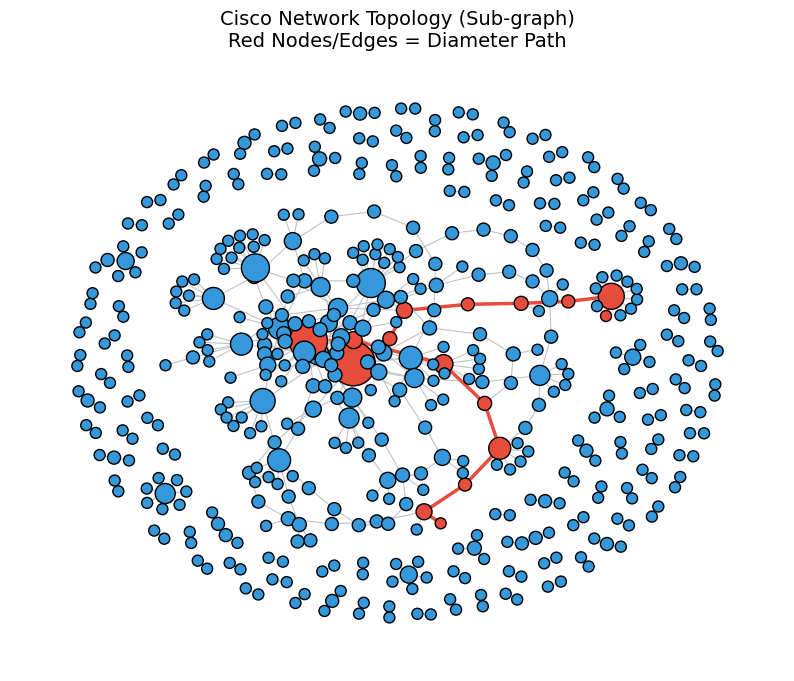

In [21]:

# Find the specific path that defines the graph diameter
diameter_path = g.get_diameter(directed=False)
diameter_edges = set(zip(diameter_path[:-1], diameter_path[1:]))

# Visual Styling Setup
# 1. Node Colors: Highlight diameter path in Red, others blue-grey based on degree
node_colors = []
for v in g.vs:
    if v.index in diameter_path:
        node_colors.append("#E74C3C")  # Bright Red for Diameter Nodes
    else:
        node_colors.append("#3498DB")  # Soft Blue for Standard Nodes

# 2. Node Sizes proportional to degree centrality
node_sizes = [10 + (d * 1.5) for d in degrees]

# 3. Edge Colors: Highlight edges on the diameter path
edge_colors = []
for e in g.es:
    source, target = e.tuple
    if (source, target) in diameter_edges or (target, source) in diameter_edges:
        edge_colors.append("#E74C3C")
    else:
        edge_colors.append("#BDC3C7")

# Layout algorithm (Fruchterman-Reingold force-directed)
layout = g.layout_fruchterman_reingold()

# Plot using igraph
fig, ax = plt.subplots(figsize=(10, 8))
ig.plot(
    g,
    target=ax,
    layout=layout,
    vertex_color=node_colors,
    vertex_size=node_sizes,
    vertex_label=None,  # Set to g.vs["name"] if labels are desired
    edge_color=edge_colors,
    edge_width=[2.5 if c == "#E74C3C" else 0.8 for c in edge_colors]
)

plt.title("Cisco Network Topology (Sub-graph)\nRed Nodes/Edges = Diameter Path", fontsize=14)
plt.show()